# GRASSY Training Evaluation - α=5.0

This notebook visualizes the latent space embeddings from GRASSY training with α=5.0 (high property prediction emphasis).


In [ ]:
# Compute all 13 properties from the dataset
import numpy as np
import sys
import os
sys.path.insert(0, os.getcwd())

from datasets.load_ZINC_tranche import ZINCDataset
from tqdm import tqdm

print("Loading dataset...")
dataset = ZINCDataset('datasets/ZINC12K.npy', prop_stat_dict='datasets/ZINC12K_stats.npy')
print(f"Dataset size: {len(dataset)}")

# Extract all 13 properties for all molecules
print("Extracting all 13 properties...")
all_props = []
for i in tqdm(range(len(dataset))):
    props = dataset[i][1]  # Get all 13 properties (z-scored)
    all_props.append(props)

all_props = np.array(all_props).T  # Shape: (13, num_molecules)
print(f"Properties shape: {all_props.shape}")

# Save it
output_path = 'scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-10-55-28/embedding_prop_lists_all.npy'
np.save(output_path, all_props)
print(f"✅ Saved all 13 properties to: {output_path}")

In [ ]:
# Run the visualization script
import subprocess
import os
from pathlib import Path

# Create output directory
outdir = 'figs/zinc12k_evaluation_a5'
os.makedirs(outdir, exist_ok=True)

# Run visualization with all 13 properties
cmd = [
    'python', 'visualize_latent_embeddings.py',
    '--embedding', 'scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-10-55-28/ordered_embedding_ZINC12K_regress_nokld.npy',
    '--labels', 'scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-10-55-28/embedding_prop_lists_all.npy',
    '--outdir', outdir,
    '--no-show'
]

print("Running visualization script (α=5.0) with all 13 properties...")
print(f"Command: {' '.join(cmd)}")
print()

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors/Warnings:")
    print(result.stderr)

if result.returncode == 0:
    print("\n✅ Visualization complete!")
    print(f"Figures saved to: {outdir}")
    
    fig_files = list(Path(outdir).glob('*.png'))
    if fig_files:
        print("\nGenerated figures:")
        for f in sorted(fig_files):
            print(f"  - {f.name}")
else:
    print(f"\n❌ Visualization failed with return code {result.returncode}")

Running visualization script (α=5.0)...
Command: python visualize_latent_embeddings.py --embedding scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-10-55-28/ordered_embedding_ZINC12K_regress_nokld.npy --labels scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-10-55-28/embedding_prop_lists_ZINC12K_regress_nokld.npy --outdir figs/zinc12k_evaluation_a5 --no-show

Loading embedding: scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-10-55-28/ordered_embedding_ZINC12K_regress_nokld.npy
Embedding shape: (11994, 25)
Loading labels: scripts/final_logs/ZINC12K_regress_nokld_2026-01-13-10-55-28/embedding_prop_lists_ZINC12K_regress_nokld.npy
Labels shape: (11994, 4)
Computing PCA...
Explained variance ratio (PCA): [0.19262367 0.13228272]
Computing PHATE...
Calculating PHATE...
  Running PHATE on 11994 observations and 25 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 31.24 seconds.
    Calculating affinities...
    Calcula

Found 8 figure(s):

📊 latent_pca_prop1.png


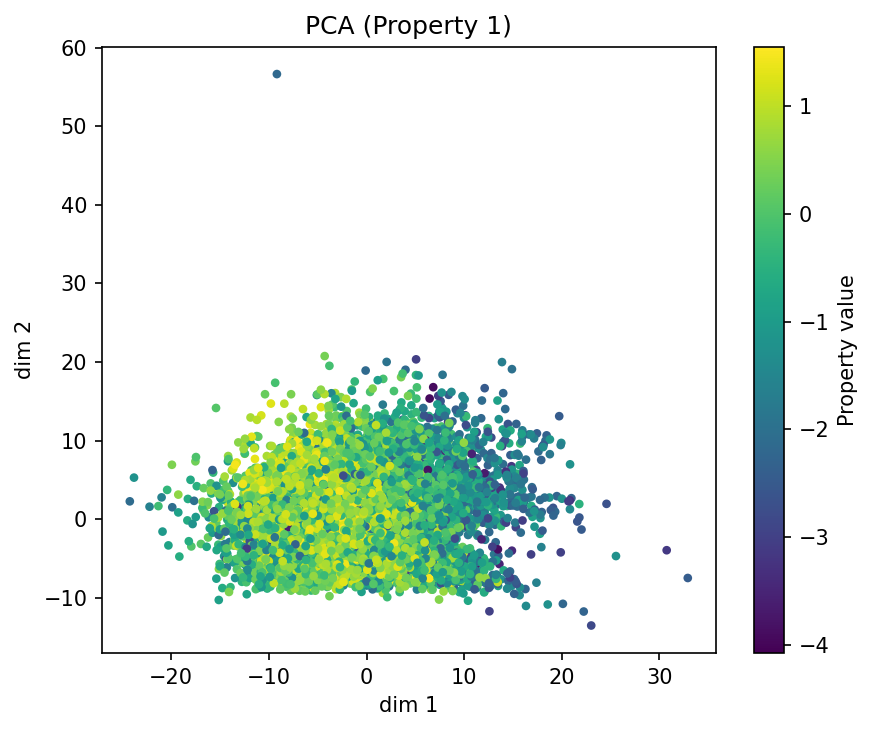


📊 latent_pca_prop2.png


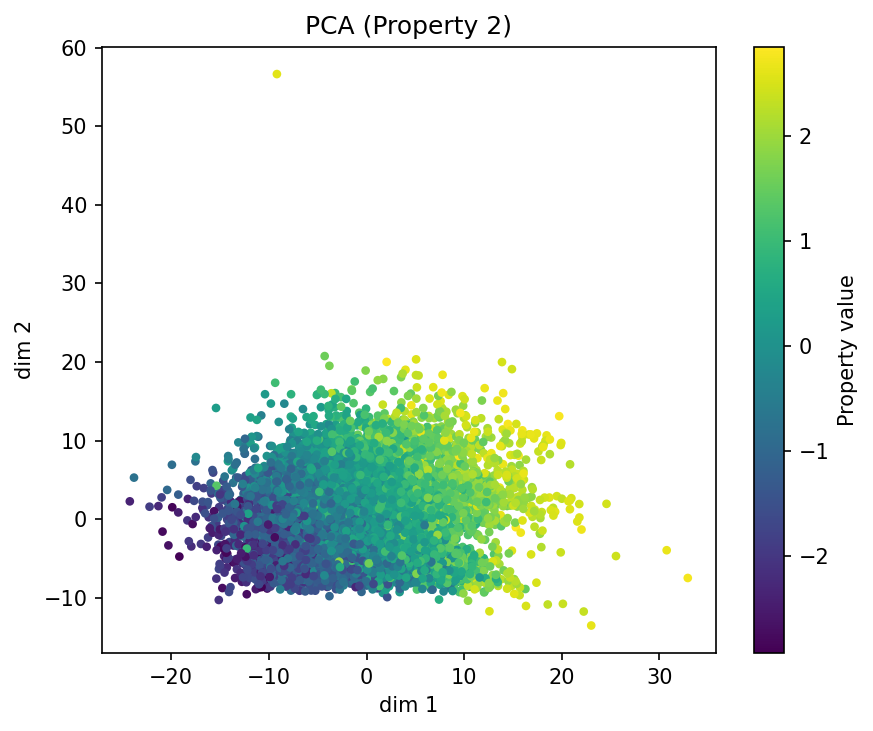


📊 latent_pca_prop3.png


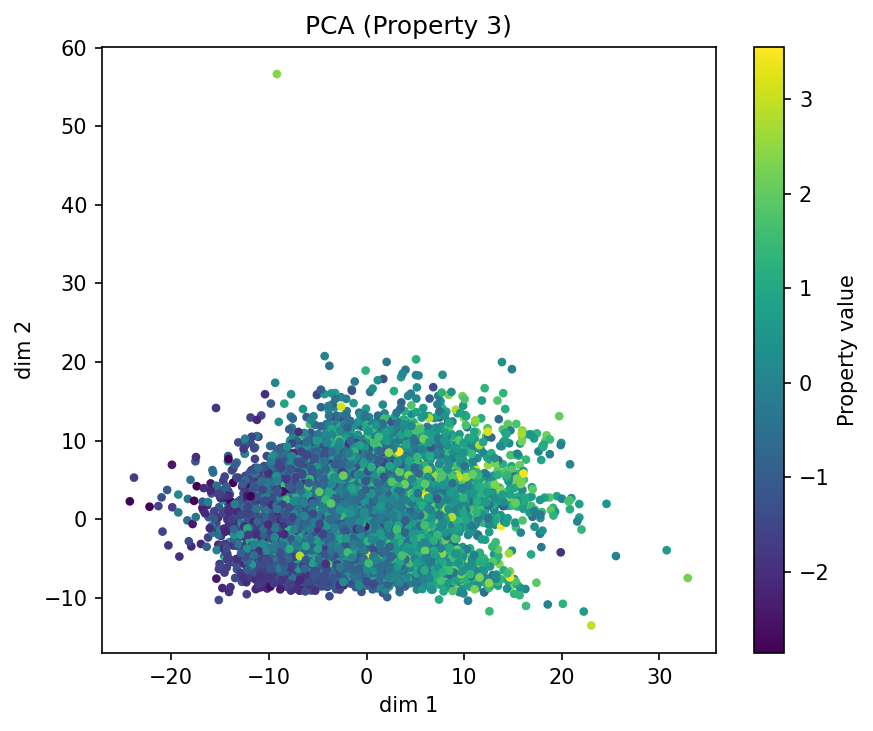


📊 latent_pca_prop4.png


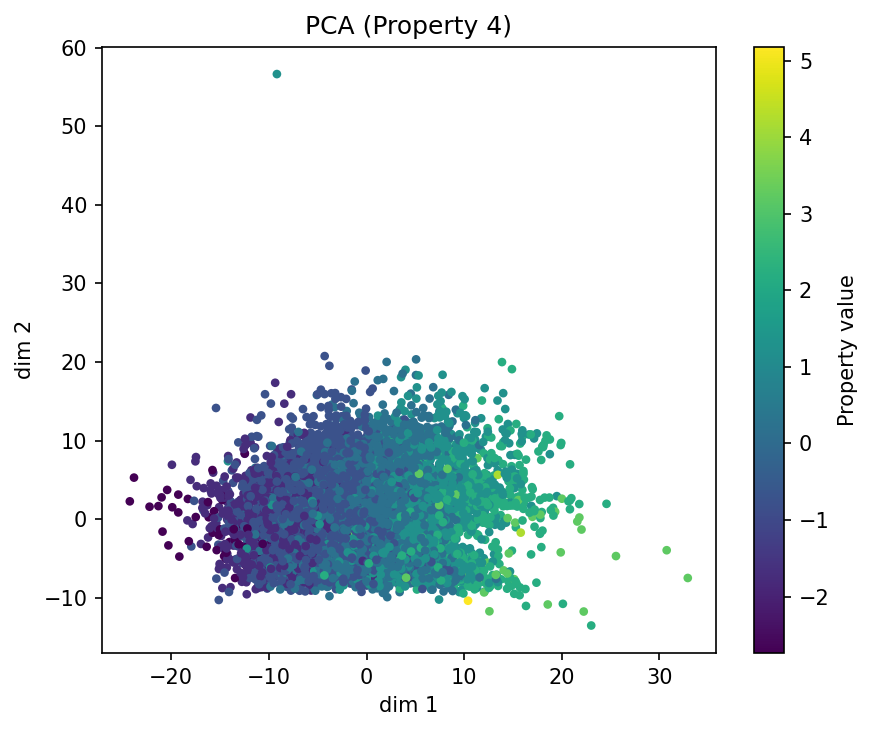


📊 latent_phate_prop1.png


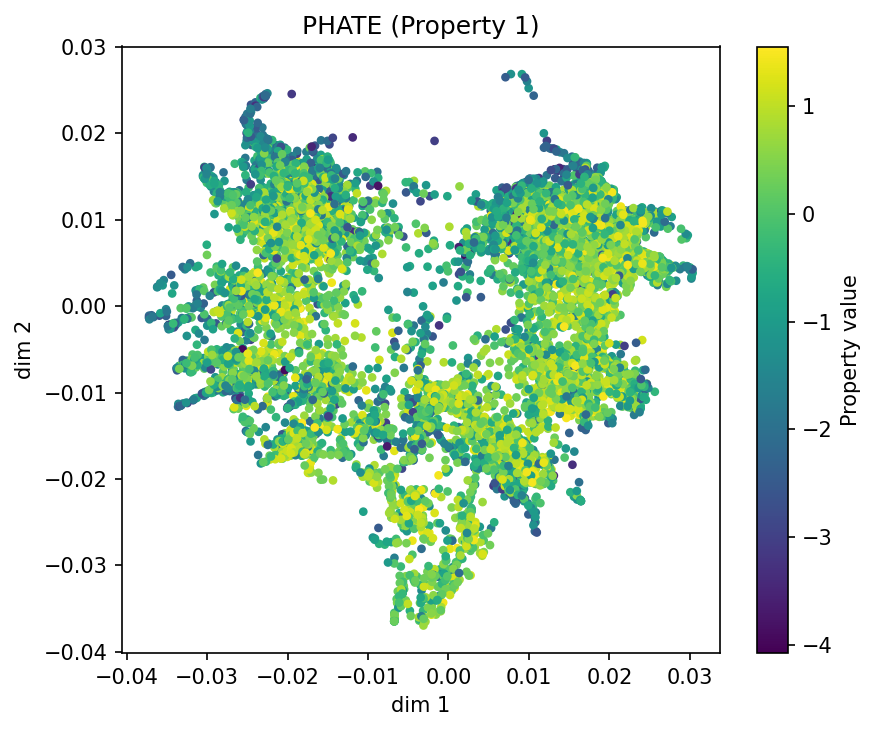


📊 latent_phate_prop2.png


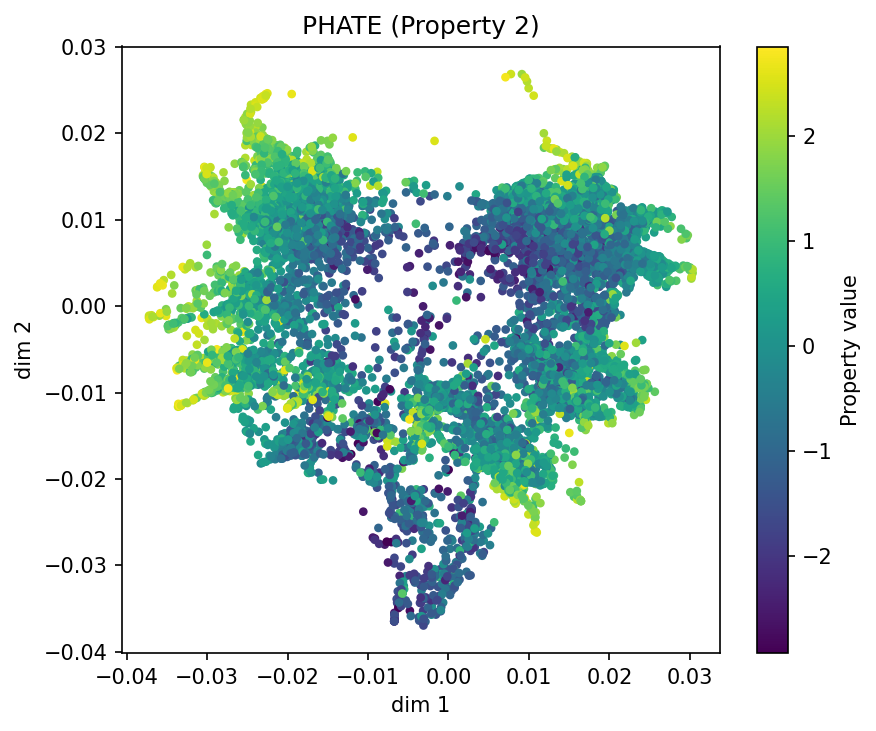


📊 latent_phate_prop3.png


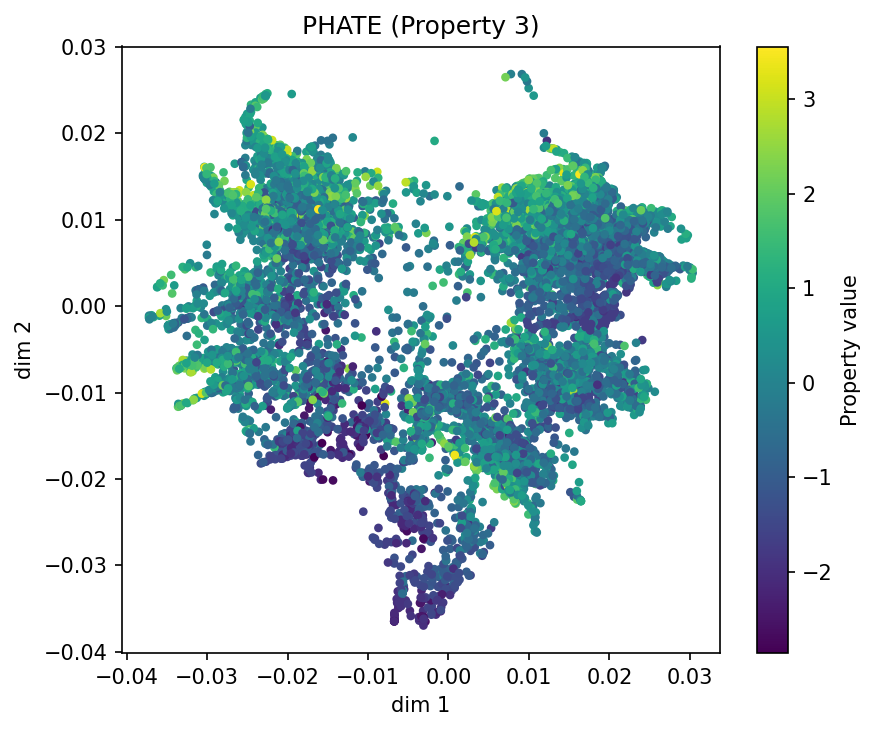


📊 latent_phate_prop4.png


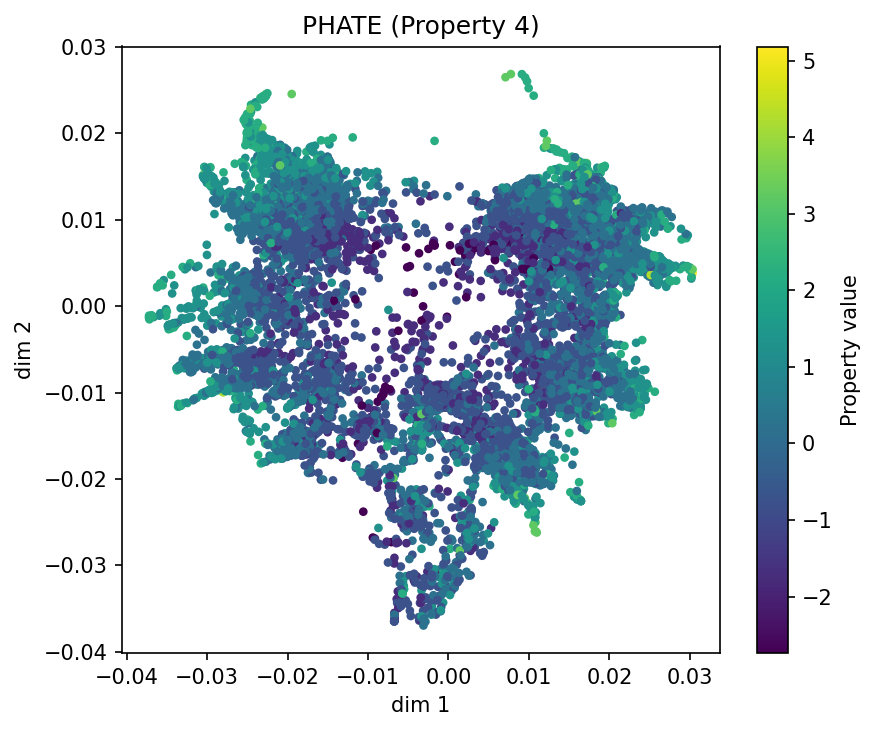

In [2]:
# Display the generated figures
from IPython.display import Image, display
import glob

fig_files = sorted(glob.glob(f'{outdir}/*.png'))
if fig_files:
    print(f"Found {len(fig_files)} figure(s):\n")
    for fig_path in fig_files:
        print(f"📊 {Path(fig_path).name}")
        display(Image(fig_path))
        print()
else:
    print(f"No figures found in {outdir}")
